# Exploration — QRIS Synthetic Merchant Generator

Scratchpad for tuning archetype parameters and eyeballing plots.
Real logic lives in `generator.py` — this notebook only imports and visualizes it.

Workflow: tweak params here -> plot -> if it looks right, that's the config worth keeping.
If the logic itself needs to change (not just params), edit `generator.py`, then re-run
the import cell below to pick up the change.

In [16]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from generator import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Steady archetype — validated baseline (residential, default)

In [27]:
result = generate_steady_merchant(seed=42)
df = result["data"]
print(result["archetype"], result["expected_eligible"], result["params"])
df.head()

steady True {'base_revenue': 500000, 'noise_sigma': 0.08, 'location_type': 'residential'}


,date,revenue
0,2025-01-01,512338.461781
1,2025-01-02,460084.132695
2,2025-01-03,530937.437466
3,2025-01-04,619935.362213
4,2025-01-05,491905.795553


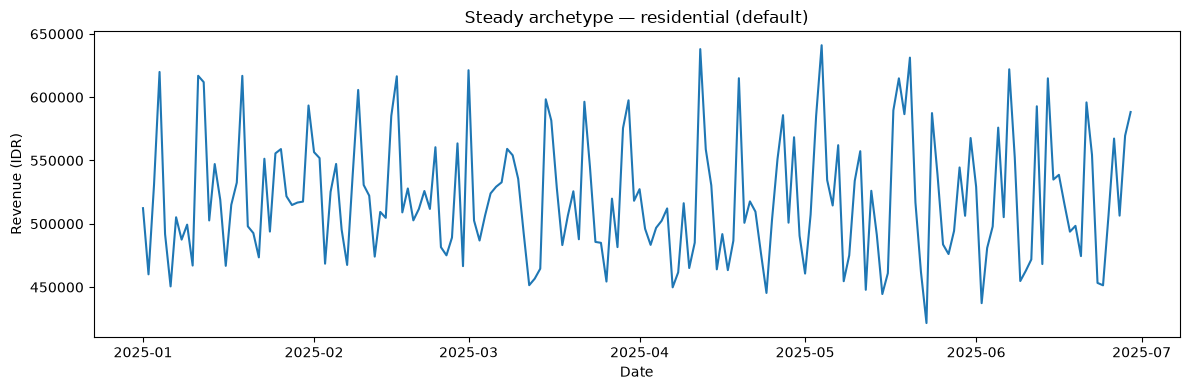

In [28]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["revenue"])
ax.set_title("Steady archetype — residential (default)")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue (IDR)")
plt.tight_layout()
plt.show()

## location_type comparison — all four side by side

Checklist while eyeballing, per design doc:
- **residential** — mild, regular weekend bumps
- **office_district** — visible weekend *drop*, weekday-high
- **attraction** — weekend peaks, weekday-low
- **market** — flattest of the four, no strong weekly rhythm

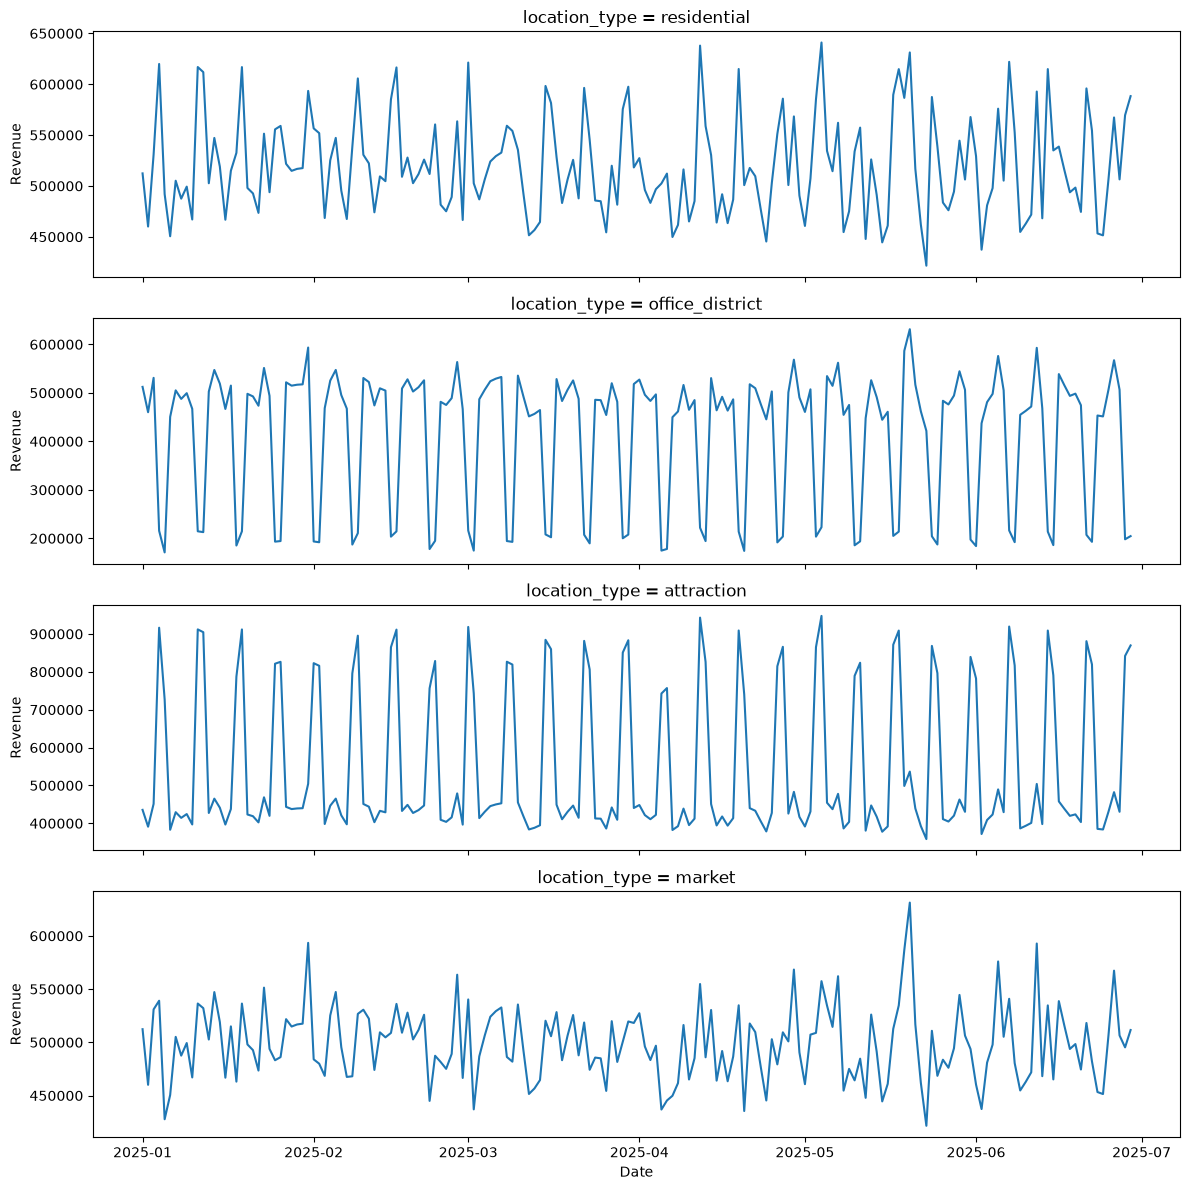

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

location_types = ["residential", "office_district", "attraction", "market"]

for ax, loc in zip(axes, location_types):
    result = generate_steady_merchant(location_type=loc, seed=42)
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"location_type = {loc}")
    ax.set_ylabel("Revenue")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## Zoomed view — first 4 weeks, one location_type at a time

180 days compressed into one chart can blur the weekly cycle. Zooming into
4 weeks with markers on each day makes the pattern unambiguous. Change
`loc` below to check a different location_type.

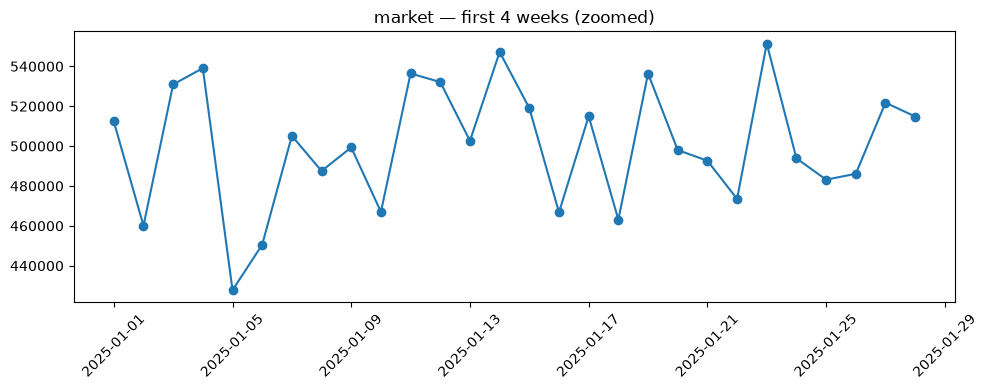

In [15]:
loc = "market"  # change to residential / attraction / market to inspect others

result = generate_steady_merchant(location_type=loc, seed=42)
d = result["data"].head(28)  # first 4 weeks only

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d["date"], d["revenue"], marker="o")
ax.set_title(f"{loc} — first 4 weeks (zoomed)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Noise sensitivity sweep (kept from earlier validation)

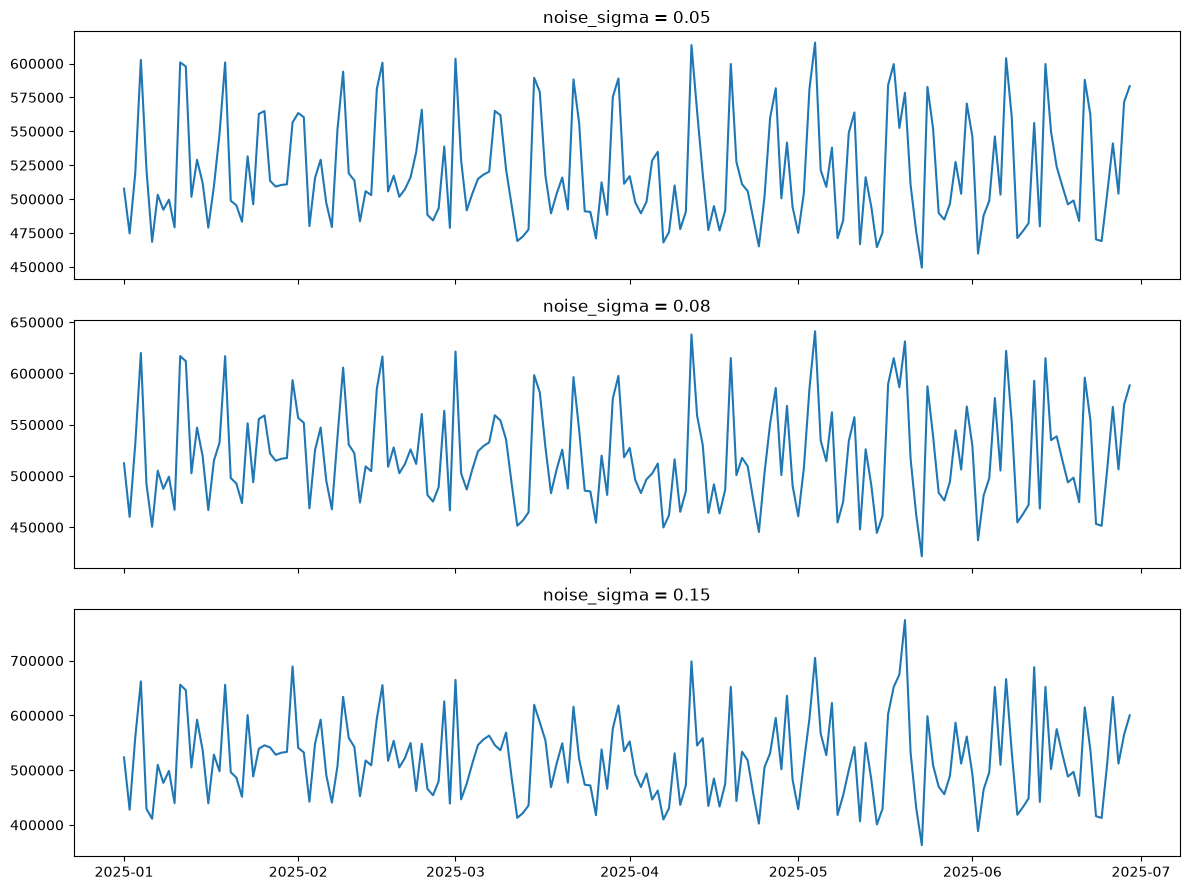

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, sigma in zip(axes, [0.05, 0.08, 0.15]):
    result = generate_steady_merchant(noise_sigma=sigma, seed=42)
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"noise_sigma = {sigma}")

plt.tight_layout()
plt.show()

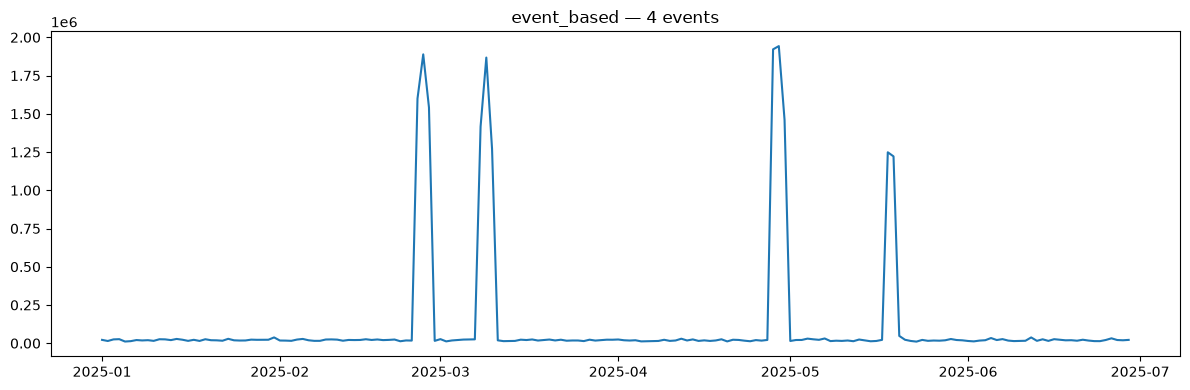

In [3]:
result = generate_event_based_merchant(seed=42)
df = result["data"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["revenue"])
ax.set_title(f"event_based — {result['params']['n_events']} events")
plt.tight_layout()
plt.show()

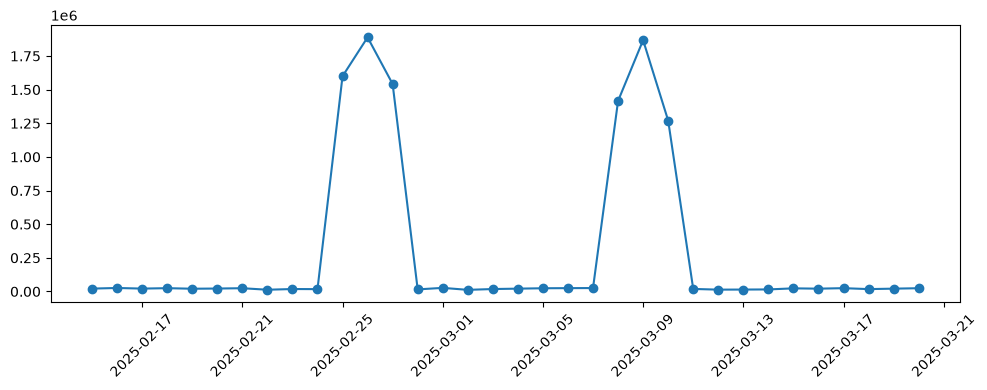

In [4]:
zoomed = df[(df["date"] >= "2025-02-15") & (df["date"] <= "2025-03-20")]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(zoomed["date"], zoomed["revenue"], marker="o")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

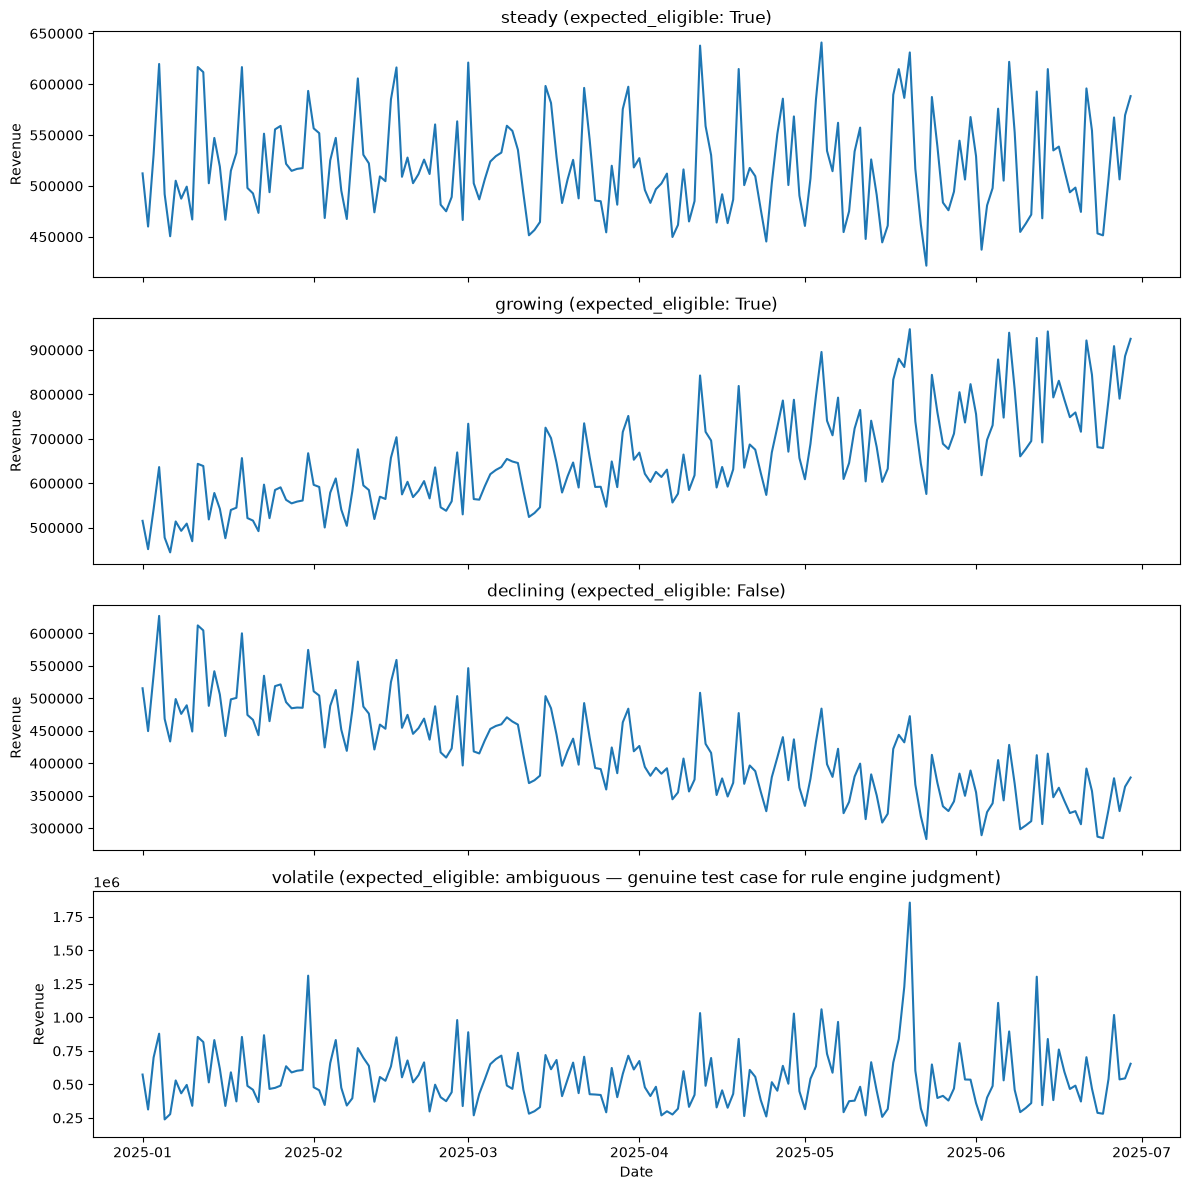

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for ax, name in zip(axes, ["steady", "growing", "declining", "volatile"]):
    result = generate_merchant(seed=42, **ARCHETYPE_CONFIGS[name])
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"{name} (expected_eligible: {result['expected_eligible']})")
    ax.set_ylabel("Revenue")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

declining False {'base_revenue': 500000, 'trend_slope': -0.0025, 'noise_sigma': 0.1, 'location_type': 'residential'}


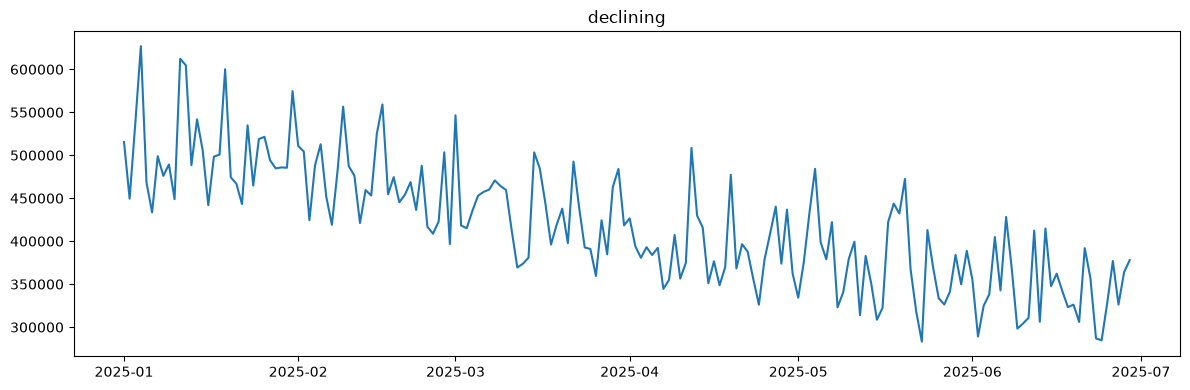

In [9]:
name = "declining"  # try: steady / growing / declining / volatile

result = generate_merchant(seed=42, **ARCHETYPE_CONFIGS[name])
print(result["archetype"], result["expected_eligible"], result["params"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(result["data"]["date"], result["data"]["revenue"])
ax.set_title(name)
plt.tight_layout()
plt.show()

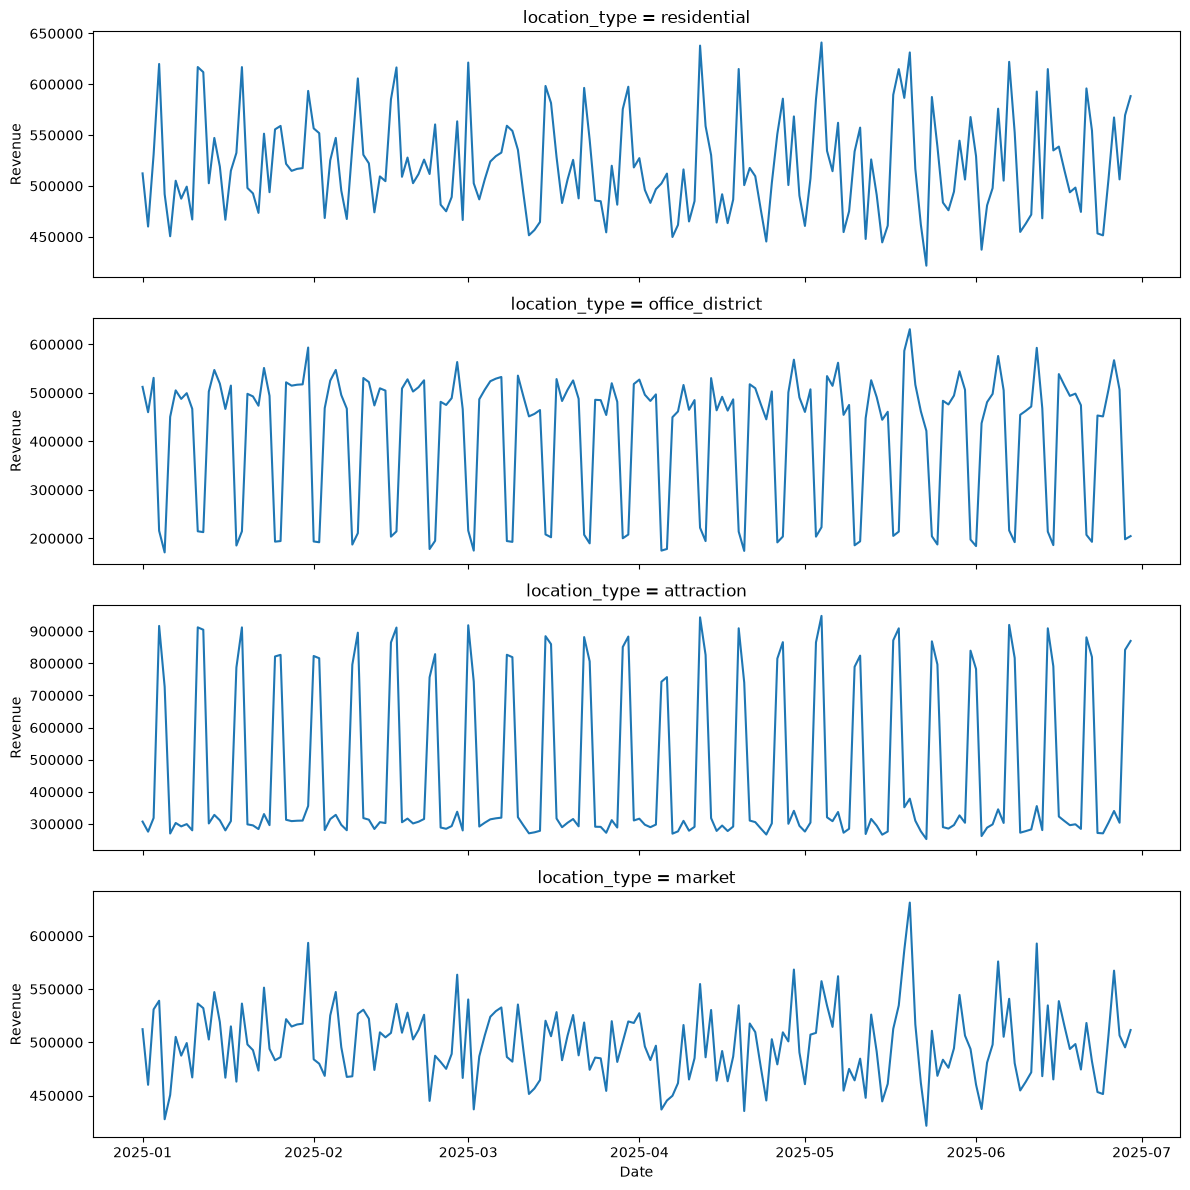

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

location_types = ["residential", "office_district", "attraction", "market"]

for ax, loc in zip(axes, location_types):
    result = generate_merchant(location_type=loc, seed=42, **ARCHETYPE_CONFIGS["steady"])
    d = result["data"]
    ax.plot(d["date"], d["revenue"])
    ax.set_title(f"location_type = {loc}")
    ax.set_ylabel("Revenue")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

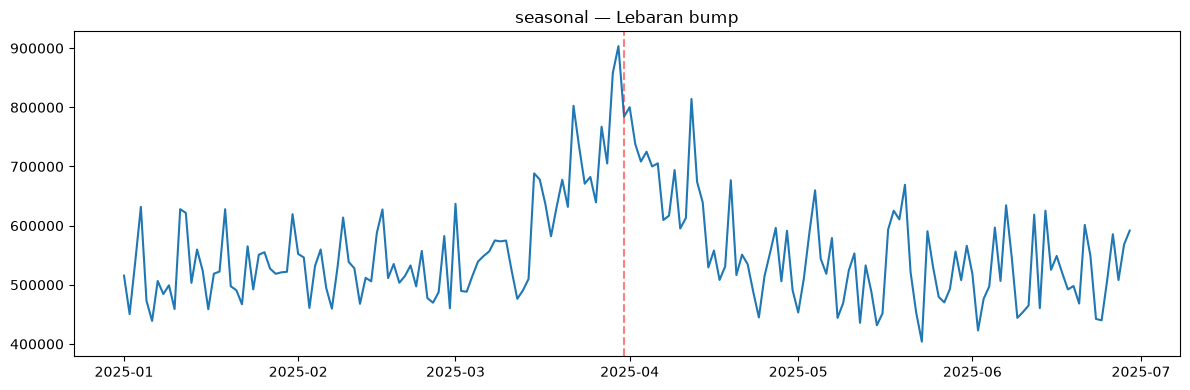

In [3]:
result = generate_merchant(seed=42, **ARCHETYPE_CONFIGS["seasonal"])
df = result["data"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["revenue"])
ax.axvline(pd.to_datetime(result["params"]["seasonal_peak_date"]), color="red", linestyle="--", alpha=0.5)
ax.set_title("seasonal — Lebaran bump")
plt.tight_layout()
plt.show()

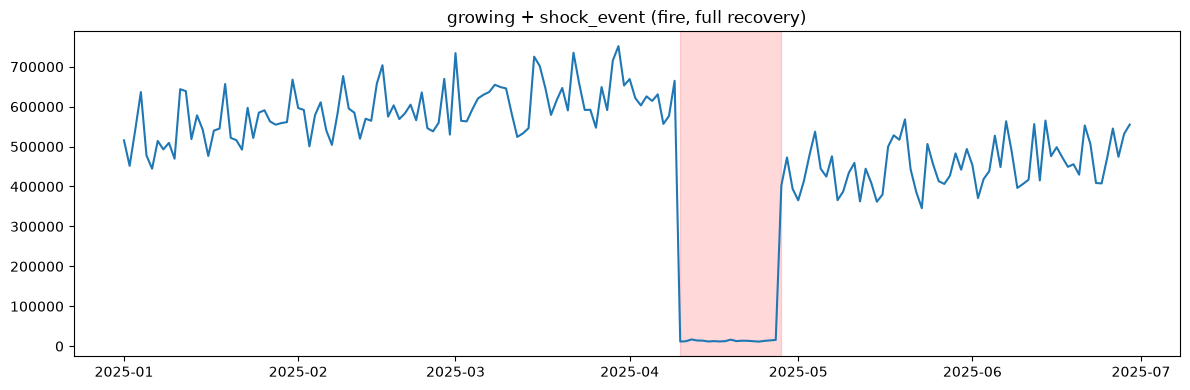

In [8]:
result = generate_merchant(seed=42, **ARCHETYPE_CONFIGS["growing"])
df = result["data"].copy()
df["revenue"] = apply_shock_event(df["revenue"].values, df["date"], shock_date="2025-04-10", duration_days=18, recovery="partial")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["revenue"])
ax.axvspan(pd.to_datetime("2025-04-10"), pd.to_datetime("2025-04-10") + pd.Timedelta(days=18), color="red", alpha=0.15)
ax.set_title("growing + shock_event (fire, full recovery)")
plt.tight_layout()
plt.show()

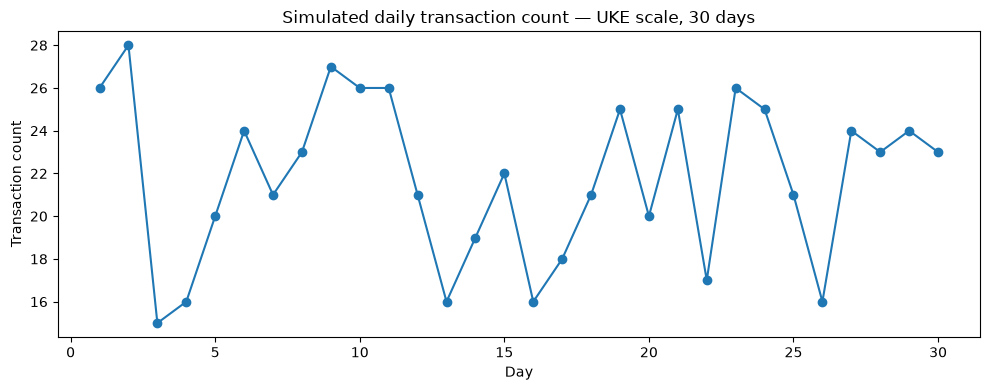

min=15, max=28, mean=21.8


In [5]:
# from generator import sample_daily_transaction_counts, BUSINESS_SCALE_TRANSACTION_COUNT

counts = sample_daily_transaction_counts(days=30, base_count=BUSINESS_SCALE_TRANSACTION_COUNT["UKE"], seed=42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 31), counts, marker="o")
ax.set_title("Simulated daily transaction count — UKE scale, 30 days")
ax.set_xlabel("Day")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.show()

print(f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

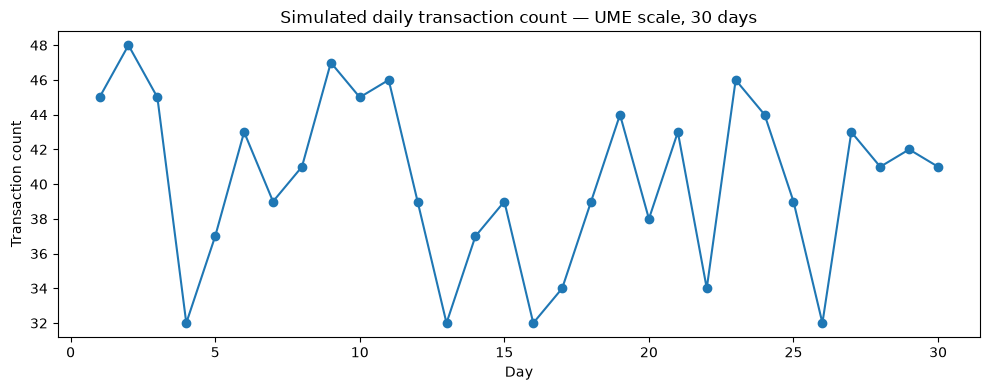

min=32, max=48, mean=40.2


In [6]:
counts = sample_daily_transaction_counts(days=30, base_count=BUSINESS_SCALE_TRANSACTION_COUNT["UME"], seed=42)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 31), counts, marker="o")
ax.set_title("Simulated daily transaction count — UME scale, 30 days")
ax.set_xlabel("Day")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.show()

print(f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

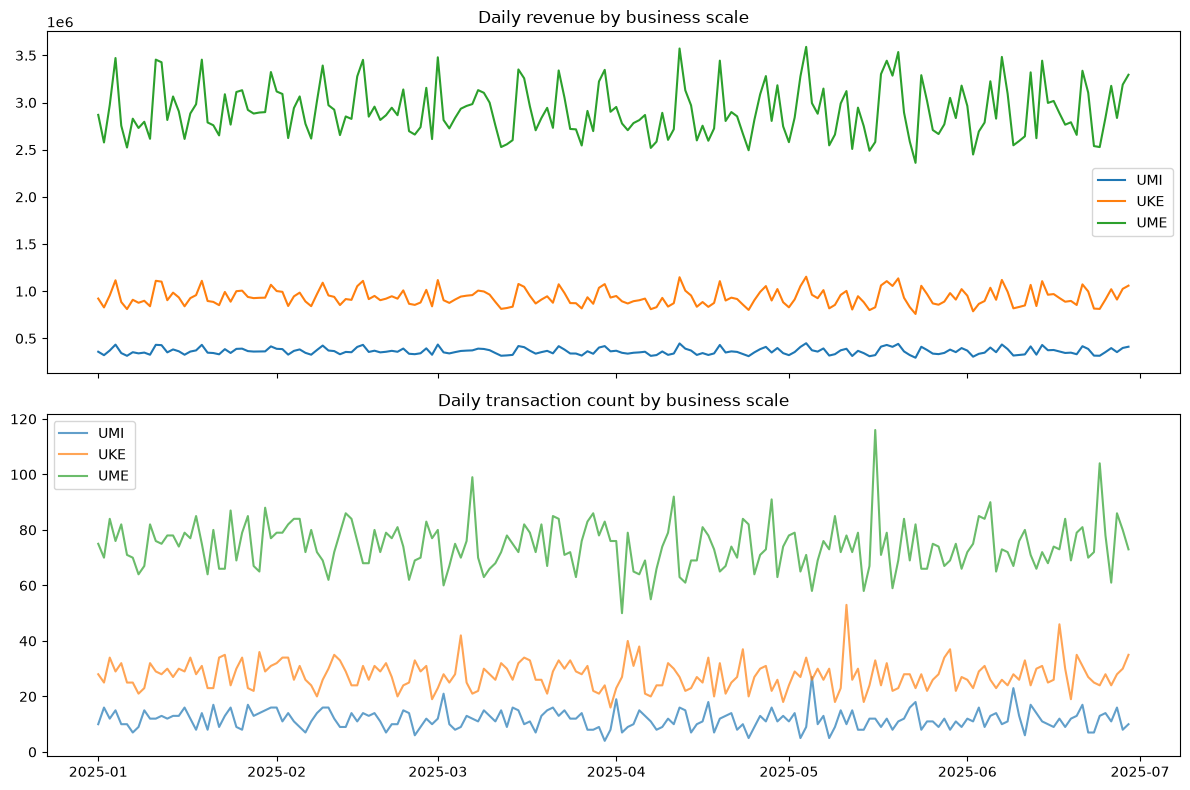

In [15]:
scales = ["UMI", "UKE", "UME"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for scale in scales:
    cfg = {k: v for k, v in ARCHETYPE_CONFIGS["steady"].items() if k != "base_revenue"}
    result = generate_merchant(merchant_business_scale=scale, seed=42, **cfg)
    d = result["data"]
    axes[0].plot(d["date"], d["revenue"], label=scale)

    counts = sample_daily_transaction_counts(
        days=180, base_count=BUSINESS_SCALE_CONFIGS[scale]["base_count"], seed=1
    )
    axes[1].plot(d["date"], counts, label=scale, alpha=0.7)

axes[0].set_title("Daily revenue by business scale")
axes[0].legend()
axes[1].set_title("Daily transaction count by business scale")
axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
pd.read_csv("synthetic_merchants/SYN-steady-UKE-42.csv").head()

,merchant_id,date,amount,type,pop_name,rrn,mcc,merchant_business_scale,business_type,archetype,expected_eligible
0,SYN-steady-UKE-42,2025-01-01,19054.05,credit,POP-SYN-steady-UKE-42,210585694770,5812,UKE,coffee_shop,steady,True
1,SYN-steady-UKE-42,2025-01-01,25212.97,credit,POP-SYN-steady-UKE-42,289631980010,5812,UKE,coffee_shop,steady,True
2,SYN-steady-UKE-42,2025-01-01,22806.39,credit,POP-SYN-steady-UKE-42,163287997202,5812,UKE,coffee_shop,steady,True
3,SYN-steady-UKE-42,2025-01-01,9547.33,credit,POP-SYN-steady-UKE-42,228052260329,5812,UKE,coffee_shop,steady,True
4,SYN-steady-UKE-42,2025-01-01,17425.00,credit,POP-SYN-steady-UKE-42,522809661580,5812,UKE,coffee_shop,steady,True
